In [2]:
import sys; print(sys.executable) # check the virtual 

/home/artem/micromamba/envs/pdf/bin/python


/mnt/c/Users/User/Downloads/Matt


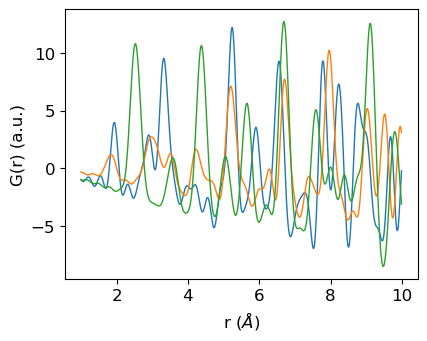

In [3]:
%cd /mnt/c/Users/User/Downloads/Matt/
%matplotlib inline
import numpy as np 
from diffpy.structure import load_structure
from diffpy.srreal.pdfcalculator import PDFCalculator
from diffpy.srreal.pdfcalculator import DebyePDFCalculator
from matplotlib.pyplot import plot, show
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (3.25, 6.5)
plt.rcParams['font.size'] = '12'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rc('lines', linewidth=1.0)
structure = load_structure('CuO.cif') # tenorite (CuO); the original 'Tenorite__0011639.cif' is not in this dir
structure2= load_structure('Cu2O.cif')
structure3= load_structure('Cu.cif')
dpc = PDFCalculator()
dpc.qmin = 1 
dpc.qmax = 20 # sets the qmax upper bound for the fourier transform
dpc.rmin = 1 
dpc.rmax = 10 # maximum r value for calculation of the PDF  




#manually set ADPs
structure[structure.element == 'Cu'].U = 0.01
structure[structure.element == 'O'].U = 0.01
structure2[structure2.element == 'Cu'].U = 0.01
structure2[structure2.element == 'O'].U = 0.01
structure3[structure3.element == 'Cu'].U = 0.01
r1, g1 = dpc(structure) #sets qmin for the lower bound of the fourier transform
r2, g2 = dpc(structure2)
r3, g3 = dpc(structure3)



plt.rcParams["figure.figsize"] = [4.55,3.5]
plt.tick_params(labelsize=12)
plt.xlabel('r ($\\AA$)')
plt.ylabel(r'G(r) (a.u.)')
plt.plot(r1,g1)
plt.plot(r2,g2)
plt.plot(r3,g3)

array = np.linspace(0,5,5001)

[[-9.78843125e-01 -8.01408969e-01 -6.56138169e-01 ... -6.62958081e-05
  -5.42784169e-05 -4.44394091e-05]
 [-1.02525275e+00 -8.39405958e-01 -6.87247472e-01 ... -6.94390735e-05
  -5.68519050e-05 -4.65464030e-05]
 [-1.06611381e+00 -8.72860163e-01 -7.14637459e-01 ... -7.22065413e-05
  -5.91177160e-05 -4.84014921e-05]
 ...
 [-1.34554366e+00 -1.10163798e+00 -9.01944891e-01 ... -9.11319722e-05
  -7.46125483e-05 -6.10875878e-05]
 [-7.59490497e-01 -6.21818226e-01 -5.09101705e-01 ... -5.14393317e-05
  -4.21149628e-05 -3.44808152e-05]
 [-2.14374448e-01 -1.75514953e-01 -1.43699490e-01 ... -1.45193105e-05
  -1.18874060e-05 -9.73258489e-06]]


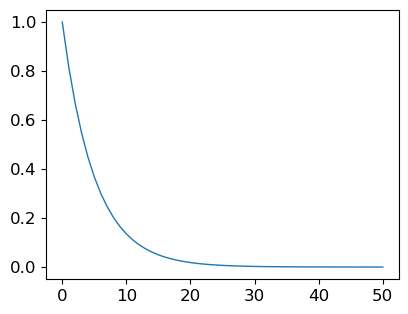

In [4]:
import numpy as np
t = np.linspace(0,5,51)
j = 0

a = np.exp(-2*t)
gt1 = np.outer(g1, a)
print(gt1)
#for i in range(gt1.shape[1]):
#    plt.plot(r1,gt1[:,i])

plt.plot(a)

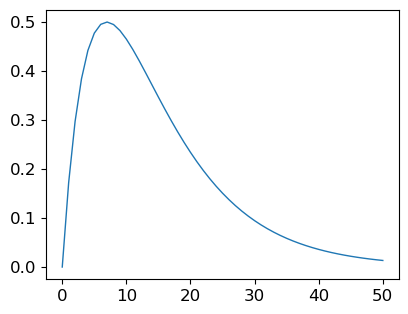

In [5]:
t = np.linspace(0,5,51)
k1=2 
k2=1
t = np.linspace(0,5,51)
denom=k2-k1
b = k1*(1/denom)*(np.exp(-k1*t)-np.exp(-k2*t))
gt2 = np.outer(g2, b)
#for i in range(gt2.shape[1]):
 #   plt.plot(r1,gt2[:,i])
#print(gt2)


plt.plot(b)


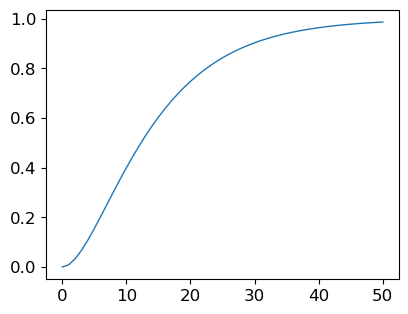

In [6]:
t = np.linspace(0,5,51)
t = np.linspace(0,5,51)
denom=k2-k1
c = 1 - a - b 
gt3 = np.outer(g3, c)
#for i in range(gt3.shape[1]):
#    plt.plot(r1,gt3[:,i])
#print(gt2)
plt.plot(c)


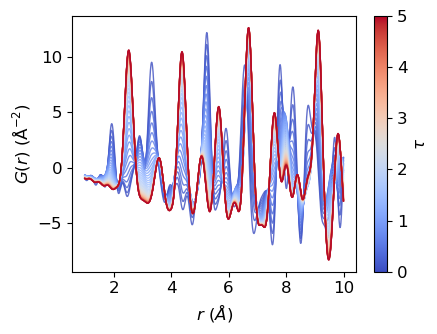

In [7]:
gt = gt1+gt2+gt3
cmap = plt.cm.coolwarm
colors = cmap(np.linspace(0, 1, len(t)))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=5))
sm.set_array([])

fi, ax = plt.subplots()
for i in range(gt.shape[1]):
    ax.plot(r1,gt[:,i], color=colors[i], alpha=0.8)

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'$\tau$')

ax.set_xlabel(r"$r$ $(\AA)$")
ax.set_ylabel(r"$G(r)$ (Å$^{-2}$)")
plt.tight_layout()
gt = gt.T
plt.savefig('KineticsSimulation.png',dpi=300)
# print(gt)

In [8]:
import typing

In [9]:
def plot_G(
    G0: np.ndarray[typing.Any]
):
    for i in range(G0.shape[1]):
        plt.plot(G0[:,i])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.optimize import nnls
from warnings import warn as Warning

gt = np.asarray(gt, dtype=float)

class Decomposition():
    def __init__(
        self,
        k: int,
        gt: np.ndarray[typing.Any],
        F: np.ndarray[typing.Any] = None, # F=[g1|g2|g3]
        g: np.ndarray[typing.Any] = None,
        method: str = "KMeans",
        offset: float = .2,
        n_init: int = 10,
        random_state: typing.Any = 0
    ):
        self.G0 = np.empty(shape=(gt.shape[0], k))
        if method == "NNLS":
            if g is None:
                self.F = np.zeros(shape=(gt.shape[1], k))
                raise Warning(
                    f"\nThe F matrix has not been initialized"
                    f"as it is not passed as one of the\n"
                    f"arguments to the object instance."
                    f"Falling back to the default initialization\n"
                    f"(F is initialized as empty matrix)"
                )
            else:
                self.F = np.asarray(a=g, dtype=float).T
        else:
            self.F = np.zeros(shape=(gt.shape[1], k))

        if self.F.shape != (gt.shape[1], k):
            raise ValueError(
                f"\nThe initialized F matrix shape {self.F.shape}"
                f"does not correspond \nto the appropriate"
                f"shape of {(gt.shape[1], k)}"
            )
        self.k = k
        self.gt = gt 
        if method == "KMeans":
            km = KMeans(n_clusters=self.k, n_init=n_init, random_state = random_state) 
            labels = km.fit_predict(gt)
            for i in range(self.G0.shape[0]): # rows
                for j in range(self.G0.shape[1]): # columns
                    if labels[i] == j:
                        self.G0[i, j] = 1
                    else:
                        self.G0[i, j] = offset
        elif method == "NNLS":
            for i in range(self.gt.shape[0]):
                self.G0[i], _ = nnls(self.F, self.gt[i])
        else:
            U, S, Vt = np.linalg.svd(self.gt, full_matrices=False)
            self.G0 = U[:, :self.k] * S[:self.k]
            for i in range(self.k):
                if np.sum(self.G0[:,i]) < 0:
                    self.G0[:,i] *= -1
                if np.min(self.G0[:,i]) < 0:
                    self.G0[:,i] -= np.min(self.G0[:,i])
        self.G0_init = self.G0
        # adding epsilon to prevent division by 0 and values of normalized G0 from blowing up
    def pos(
        self,
        A: np.ndarray
        ) -> np.ndarray:
        return (np.abs(A) + A) / 2.0

    def neg(
        self,
        A: np.ndarray
        ) -> np.ndarray:
        return (np.abs(A) - A) / 2.0
    
    def semi_nmf(
        self,
        reprod: bool = False,
        norm: bool = True,
        n_iter: float = 10**4,
        epsilon: float = 10**(-12)
    ):
        error = np.zeros(n_iter)
        if reprod == False:
            self.G0 = self.G0_init.copy()
        for i in range(n_iter):
            # phase matrix: allowed to be positive and negative
            self.F = (self.gt.T @ self.G0) @ np.linalg.pinv(self.G0.T @ self.G0)   # shape: (10001, 2)

            XF = gt @ self.F          # shape: (5, 2)
            FtF = self.F.T @ self.F       # shape: (2, 2)

            num = self.pos(XF) + self.G0 @ self.neg(FtF)
            den = self.neg(XF) + self.G0 @ self.pos(FtF) + epsilon
            self.G0 *= np.sqrt(num / den)
            if norm == True:
                self.G0 = self.G0 / (self.G0.sum(axis=1, keepdims=True))

            X_hat = self.G0 @ self.F.T    # shape: (5, 10001)
            error[i] = np.linalg.norm(gt - X_hat)

        return error


G0 shape: (51, 3)
[[0.2 0.2 1. ]
 [0.2 0.2 1. ]
 [0.2 0.2 1. ]
 [0.2 0.2 1. ]
 [0.2 0.2 1. ]
 [0.2 0.2 1. ]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [0.2 1.  0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]
 [1.  0.2 0.2]]


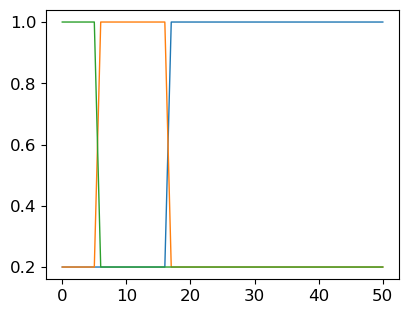

In [14]:
model_km = Decomposition(k = 3, gt = gt, method = "KMeans")

print("G0 shape:", model_km.G0.shape)  
print(model_km.G0)
plot_G(model_km.G0)

In [ ]:
error_KMeans = model_km.semi_nmf()
print(error_KMeans)

[2.42802358e+02 7.05410774e+01 6.35402529e+01 ... 1.10083628e-12
 1.04787258e-12 1.10030467e-12]


(900, 3)
(51, 3)
[[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.18730753e-01 1.72213330e-01 9.05591701e-03]
 [6.70320046e-01 2.96821414e-01 3.28585399e-02]
 [5.48811636e-01 3.84013169e-01 6.71751947e-02]
 [4.49328964e-01 4.41982164e-01 1.08688872e-01]
 [3.67879441e-01 4.77302437e-01 1.54818122e-01]
 [3.01194212e-01 4.95234848e-01 2.03570940e-01]
 [2.46596964e-01 4.99976680e-01 2.53426356e-01]
 [2.01896518e-01 4.94864892e-01 3.03238590e-01]
 [1.65298888e-01 4.82541543e-01 3.52159569e-01]
 [1.35335283e-01 4.65088316e-01 3.99576401e-01]
 [1.10803158e-01 4.44135851e-01 4.45060991e-01]
 [9.07179533e-02 4.20952517e-01 4.88329529e-01]
 [7.42735782e-02 3.96516430e-01 5.29209992e-01]
 [6.08100626e-02 3.71573803e-01 5.67616135e-01]
 [4.97870684e-02 3.46686184e-01 6.03526748e-01]
 [4.07622040e-02 3.22268628e-01 6.36969168e-01]
 [3.33732700e-02 2.98620508e-01 6.68006222e-01]
 [2.73237224e-02 2.75950332e-01 6.96725946e-01]
 [2.23707719e-02 2.54395695e-01 7.23233533e-01]
 [1.83156389e-02 2.3403

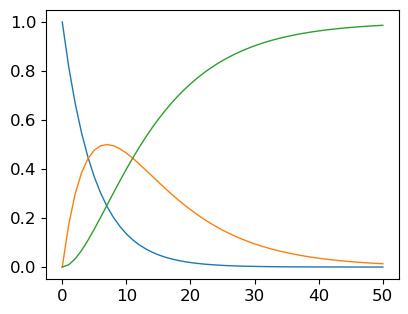

In [16]:
NNLS = Decomposition(k=3, gt = gt, method = "NNLS", g = np.array([g1, g2, g3]))

print(NNLS.F.shape)
print(NNLS.G0.shape)
print(NNLS.G0)
plot(NNLS.G0)

In [ ]:
error_NNLS = NNLS.semi_nmf()
print(error_NNLS)

[3.18644651e-13 5.95534318e-13 6.89414920e-13 ... 5.04996697e-13
 5.11175660e-13 5.09825819e-13]


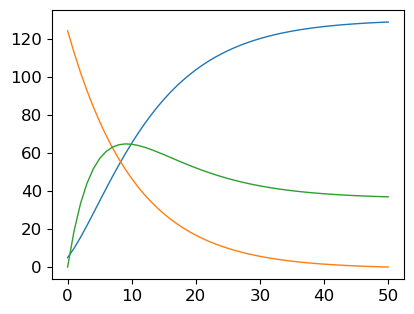

In [18]:
SVD = Decomposition(k=3, gt = gt, method = "SVD")
plot_G(SVD.G0)

In [ ]:
error_SVD = SVD.semi_nmf()
print(error_SVD) # SVD init

[7.79017435e+02 9.83476165e+00 6.68339848e+00 ... 1.10461860e-04
 1.10386615e-04 1.10311422e-04]


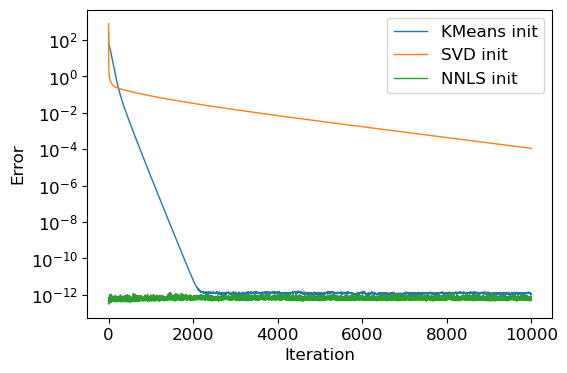

In [20]:
plt.figure(figsize = (6,4))
plt.semilogy(error_KMeans, label = "KMeans init")
plt.semilogy(error_SVD, label = "SVD init")
plt.semilogy(error_NNLS, label = "NNLS init")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.legend()
plt.show()

[[-0.97884313 -0.32494996 -0.981777  ]
 [-1.02525275 -0.32513984 -0.99692056]
 [-1.06611381 -0.32839122 -1.00894672]
 ...
 [-1.34554366  3.51206482 -2.26968488]
 [-0.7594905   3.3437125  -2.689499  ]
 [-0.21437445  3.09876168 -3.09194295]]


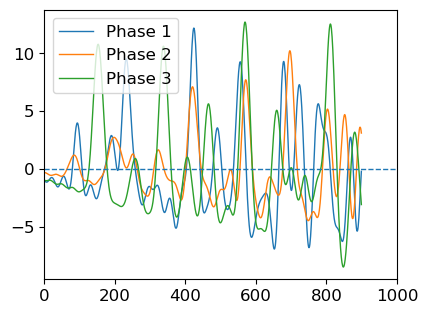

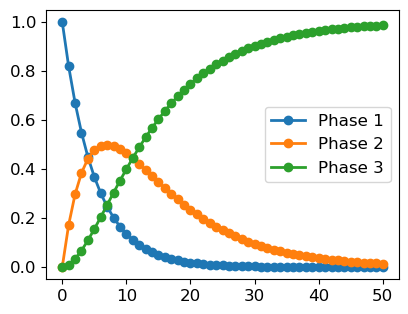

In [21]:
import matplotlib.pyplot as plt

F = NNLS.F
G0 = NNLS.G0
print(F)

plt.figure()
plt.plot(F[:, 0], label="Phase 1")
plt.plot(F[:, 1], label="Phase 2")
plt.plot(F[:, 2], label="Phase 3")
plt.axhline(0, linestyle="--")
plt.legend()
plt.xlim(0, 1000)   # zoom in if you want
plt.show()
plt.figure()

plt.plot(G0[:,0], marker="o", linewidth=2, label="Phase 1")
plt.plot( G0[:,1], marker="o", linewidth=2, label="Phase 2")
plt.plot( G0[:,2], marker="o", linewidth=2, label="Phase 3")
plt.legend()

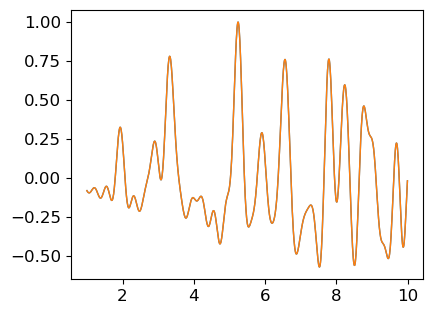

In [22]:
plt.plot(r1,F[:, 0]/max(F[:,0]), label="Phase 1")
plt.plot(r1,g1/max(g1))

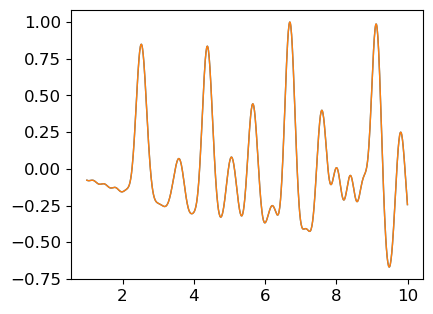

In [23]:
plt.plot(r1,F[:, 2]/max(F[:, 2]), label="Phase 2")
plt.plot(r3,g3/max(g3))

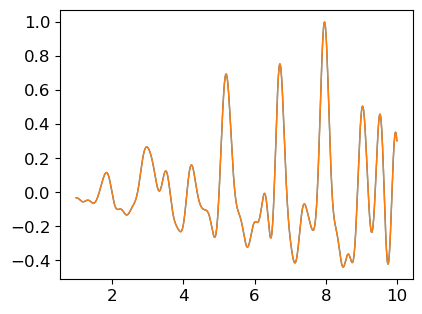

In [24]:
plt.plot(r1,F[:, 1]/max(F[:, 1]), label="Phase 3")
plt.plot(r2,g2/max(g2))